### Time Series Analysis

Convert to Time Series Format (Set Index)

In [5]:
import numpy as np
import pandas as pd
from scipy import stats

file_path = r"C:\Users\SKHAKH MUBASHSHIR\data.csv"

# CSV File load
df = pd.read_csv(file_path,encoding='latin-1')

#  preview check 
print("Dataset Shape:", df.shape)
df.head()

# 1. Date Column Convert
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# Total Revenue calculate (agar pehle se nahi hai)
if "TotalRevenue" not in df.columns:
    df["TotalRevenue"] = df["Quantity"] * df["UnitPrice"]

# Null dates remove karke index set karein
df_ts = df.dropna(subset=["InvoiceDate"]).copy()
df_ts.set_index("InvoiceDate", inplace=True)

# Sorting index by date
df_ts.sort_index(inplace=True)

print(" Time Series Format Ready!")
print("Date Range:", df_ts.index.min(), "to", df_ts.index.max())
df_ts[["Quantity", "UnitPrice", "TotalRevenue"]].head()

Dataset Shape: (541909, 8)
 Time Series Format Ready!
Date Range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


,Quantity,UnitPrice,TotalRevenue
InvoiceDate,,,
2010-12-01 08:26:00,6,2.55,15.30
2010-12-01 08:26:00,6,3.39,20.34
2010-12-01 08:26:00,8,2.75,22.00
2010-12-01 08:26:00,6,3.39,20.34
2010-12-01 08:26:00,6,3.39,20.34


Resample Data (Daily / Weekly / Monthly)

In [6]:
# Resampling Revenue at Daily, Weekly, and Monthly intervals
daily_revenue = df_ts["TotalRevenue"].resample("D").sum()
weekly_revenue = df_ts["TotalRevenue"].resample("W").sum()
monthly_revenue = df_ts["TotalRevenue"].resample("ME").sum()

print("=" * 55)
print("             TIME SERIES RESAMPLING SUMMARY             ")
print("=" * 55)
print(
    f"Total Daily Periods    : {len(daily_revenue)} days"
)
print(f"Average Daily Revenue  : ${daily_revenue.mean():.2f}")
print(f"Average Weekly Revenue : ${weekly_revenue.mean():.2f}")
print(f"Average Monthly Revenue: ${monthly_revenue.mean():.2f}")
print("=" * 55)

# Monthly Revenue DataFrame Preview
monthly_revenue.to_frame(name="Monthly_Revenue").head()

             TIME SERIES RESAMPLING SUMMARY             
Total Daily Periods    : 374 days
Average Daily Revenue  : $26063.50
Average Weekly Revenue : $180513.85
Average Monthly Revenue: $749826.76


,Monthly_Revenue
InvoiceDate,
2010-12-31,748957.020
2011-01-31,560000.260
2011-02-28,498062.650
2011-03-31,683267.080
2011-04-30,493207.121


Decompose into Trend, Seasonality, and Residuals

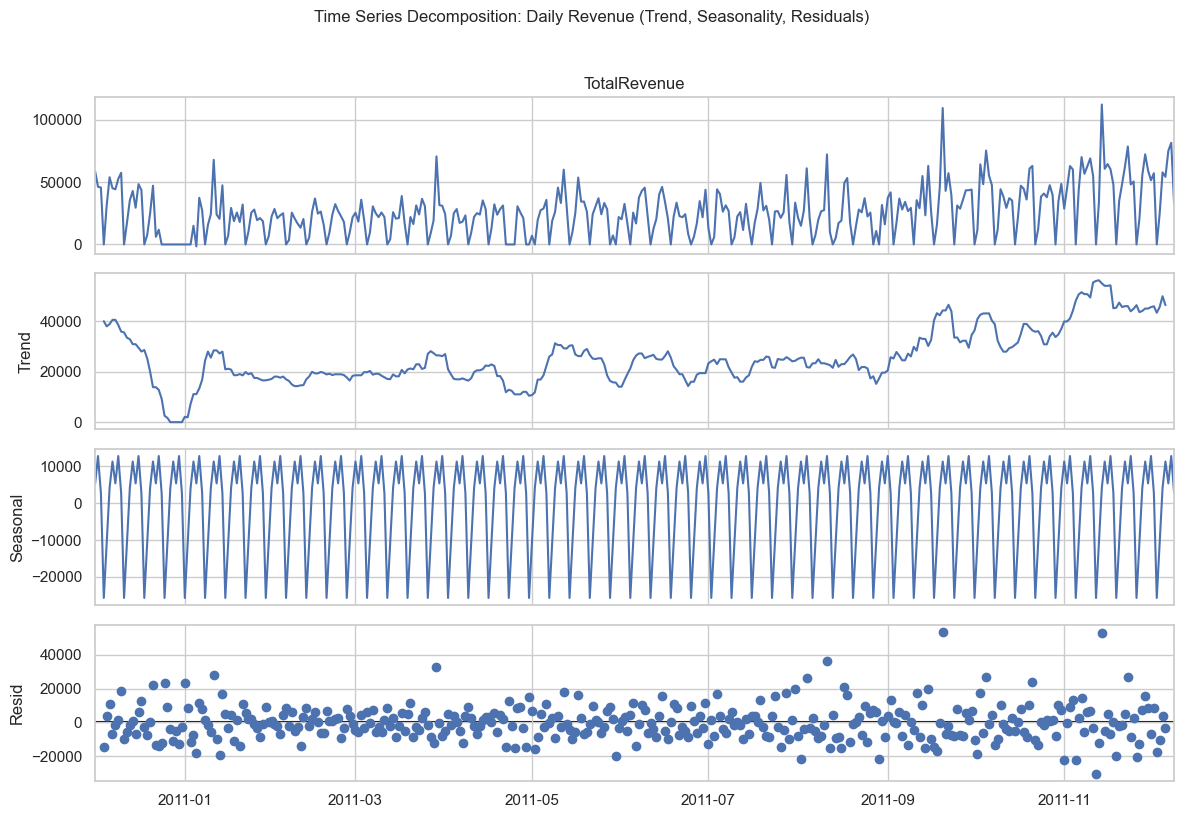

In [7]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Clean daily data (missing dates ko 0 se fill karein)
daily_revenue_clean = daily_revenue.fillna(0)

# Additive Decomposition (Period = 7 for weekly seasonality)
decomposition = seasonal_decompose(
    daily_revenue_clean, model="additive", period=7
)

# Decomposition Plot Visualisation
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle(
    "Time Series Decomposition: Daily Revenue (Trend, Seasonality, Residuals)",
    fontsize=12,
    y=1.02,
)
plt.tight_layout()
plt.show()

Build Simple Moving Average (SMA) Forecastimport matplotlib.pyplot as plt


            MOVING AVERAGE FORECAST RESULTS             
7-Day SMA Forecast for Next Day Revenue: $46453.00


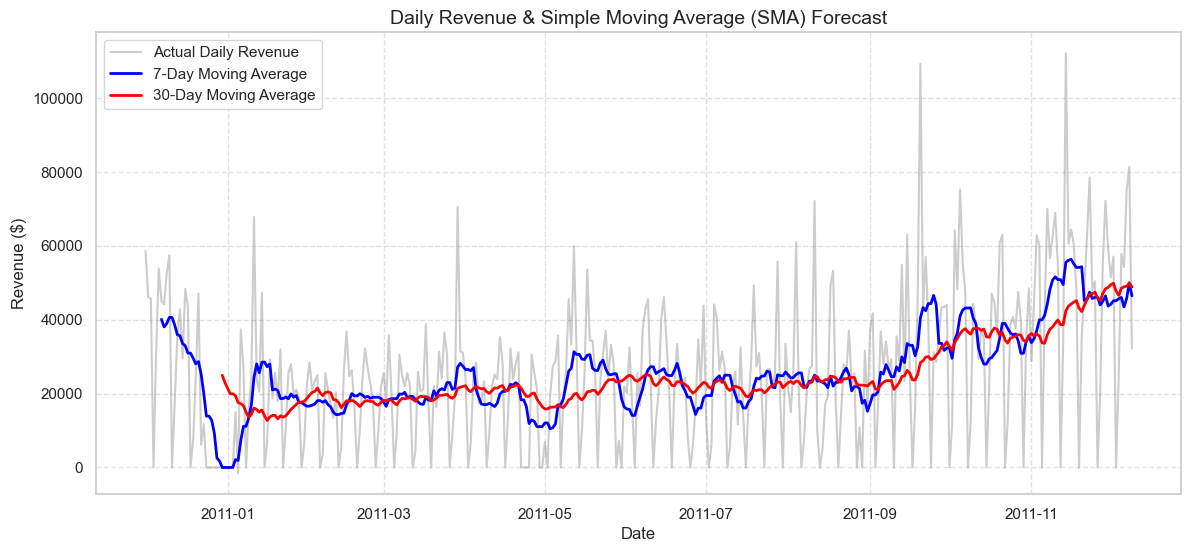

In [8]:

# 7-day aur 30-day Moving Average Columns
daily_df = pd.DataFrame({"Actual_Revenue": daily_revenue_clean})
daily_df["SMA_7_Day"] = daily_df["Actual_Revenue"].rolling(window=7).mean()
daily_df["SMA_30_Day"] = daily_df["Actual_Revenue"].rolling(window=30).mean()

# Next Day Forecast using 7-Day SMA
next_day_forecast = daily_df["SMA_7_Day"].iloc[-1]

print("=" * 55)
print("            MOVING AVERAGE FORECAST RESULTS             ")
print("=" * 55)
print(f"7-Day SMA Forecast for Next Day Revenue: ${next_day_forecast:.2f}")
print("=" * 55)

# Plotting Forecast Trend
plt.figure(figsize=(14, 6))
plt.plot(
    daily_df.index,
    daily_df["Actual_Revenue"],
    label="Actual Daily Revenue",
    alpha=0.4,
    color="gray",
)
plt.plot(
    daily_df.index,
    daily_df["SMA_7_Day"],
    label="7-Day Moving Average",
    color="blue",
    linewidth=2,
)
plt.plot(
    daily_df.index,
    daily_df["SMA_30_Day"],
    label="30-Day Moving Average",
    color="red",
    linewidth=2,
)

plt.title("Daily Revenue & Simple Moving Average (SMA) Forecast", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Revenue ($)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()